# EPS 109 "Computer Simulations in Earth and Planetary Science"
### Instructor: Burkhard Militzer
### Combined lab and homework assignment on sound and audio files: Part 7


On bCourses, read the audio recording instructions for Apple and Andoid phones. Then please record any audio signal of your choice. However, if you do not get meaningful results in the following steps, we recommend you record something else. We also ask for your recording to differ from "the other recording".

(1) Please let us know what you recorded:

I recorded A G major scale on the piano

(2) Plot the sound amplitude as function of time:

Data rate [units of Hz = 1/seconds] =  48000
Array: data
shape: (296960,)
dtype: int16
min, max: -23788 29012



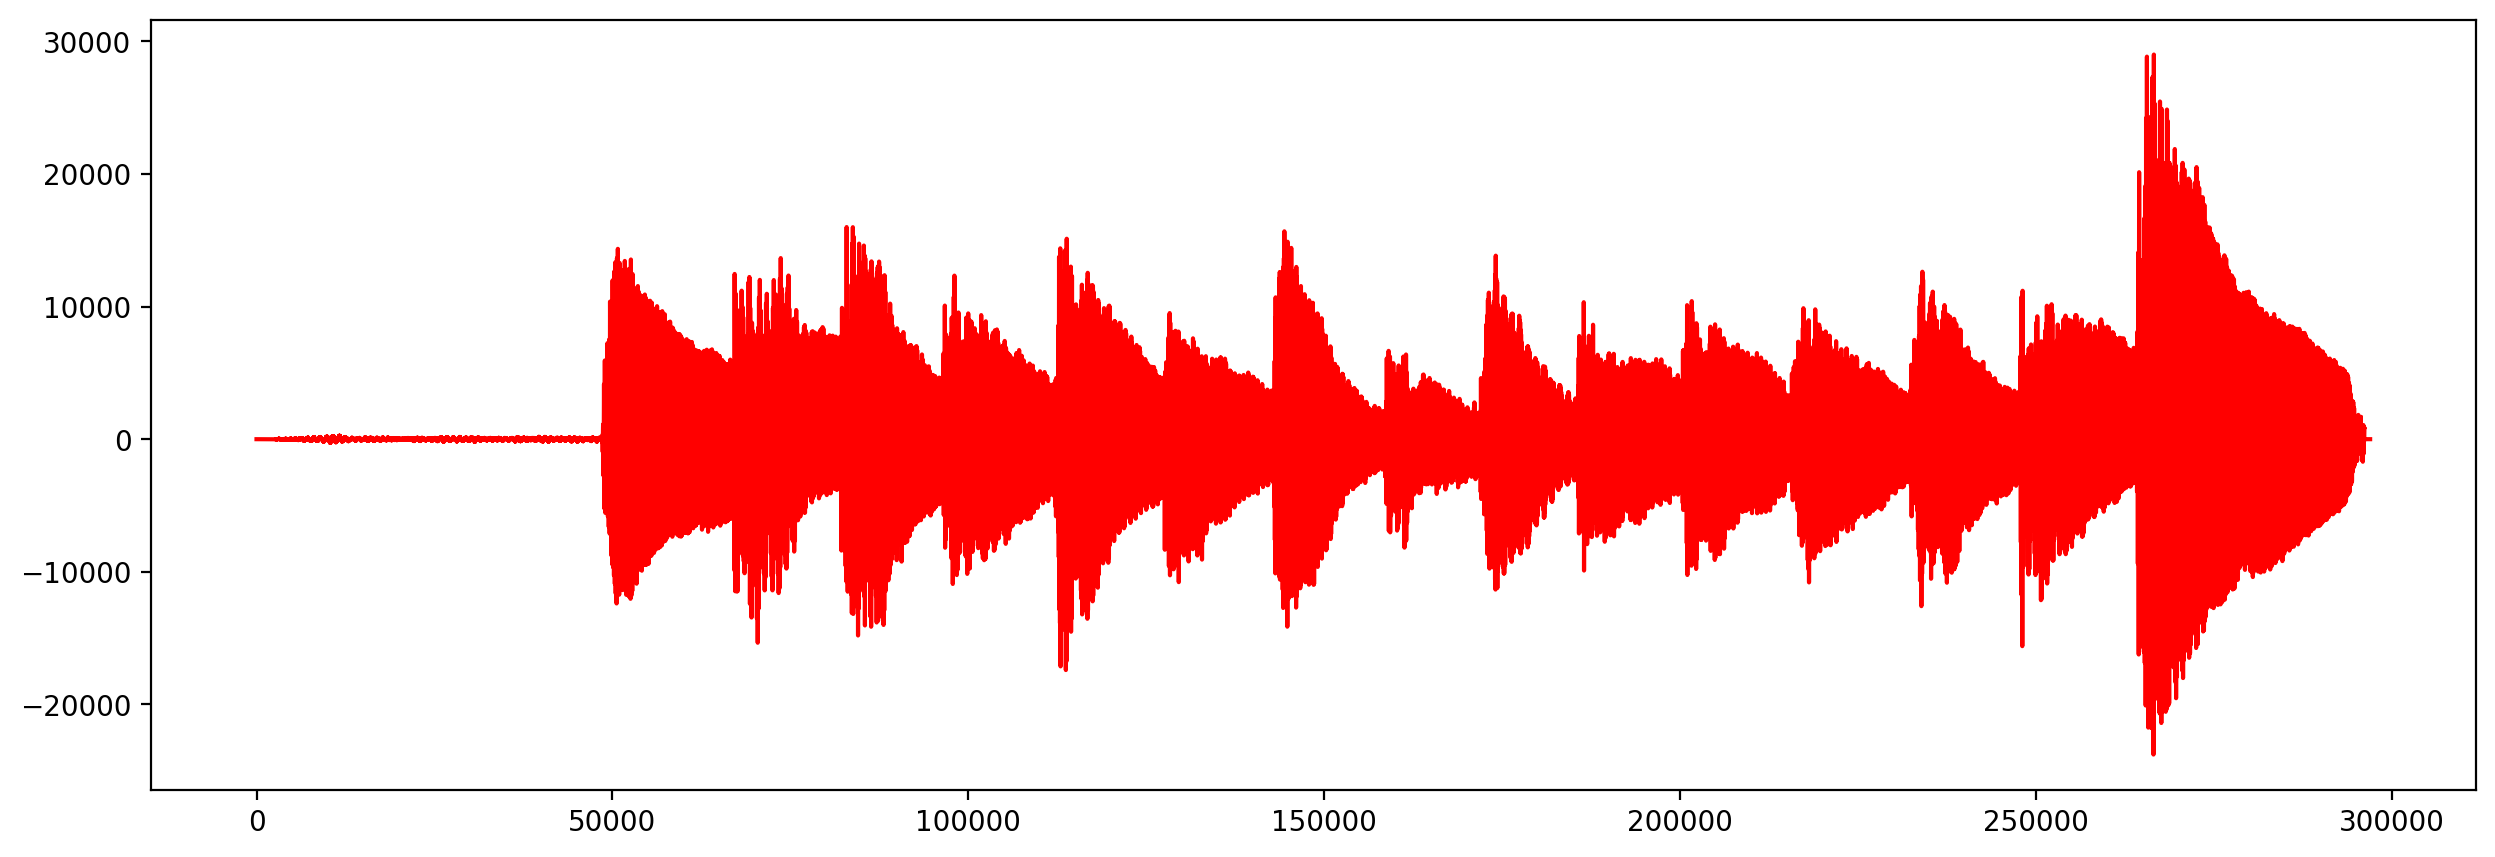

In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
import numpy as np
import simpleaudio as sa
from scipy.io import wavfile

def PrintArrayInfo(a,name=''):
    if (len(name)==0):
        print("Array info:")
    else:
        print("Array:", name)
    print("shape:", a.shape)
    print("dtype:", a.dtype)
    print("min, max:", a.min(), a.max())
    print()

filename = 'Homework13.wav'
wave_obj = sa.WaveObject.from_wave_file(filename)
#play_obj = wave_obj.play()
#play_obj.wait_done()  # Wait until sound has finished playing

rate, data = wavfile.read(filename)
print("Data rate [units of Hz = 1/seconds] = ",rate)
PrintArrayInfo(data,"data")

plt.rcParams['figure.figsize'] = [15, 5]
plt.plot(data,'r-')
plt.show()

(3) Fourier transform the entire recording starting with a frequency of your choice. We found the range from k=80...5000 to work in most cases. Then plot the Fourier transform as function of frequency index. 

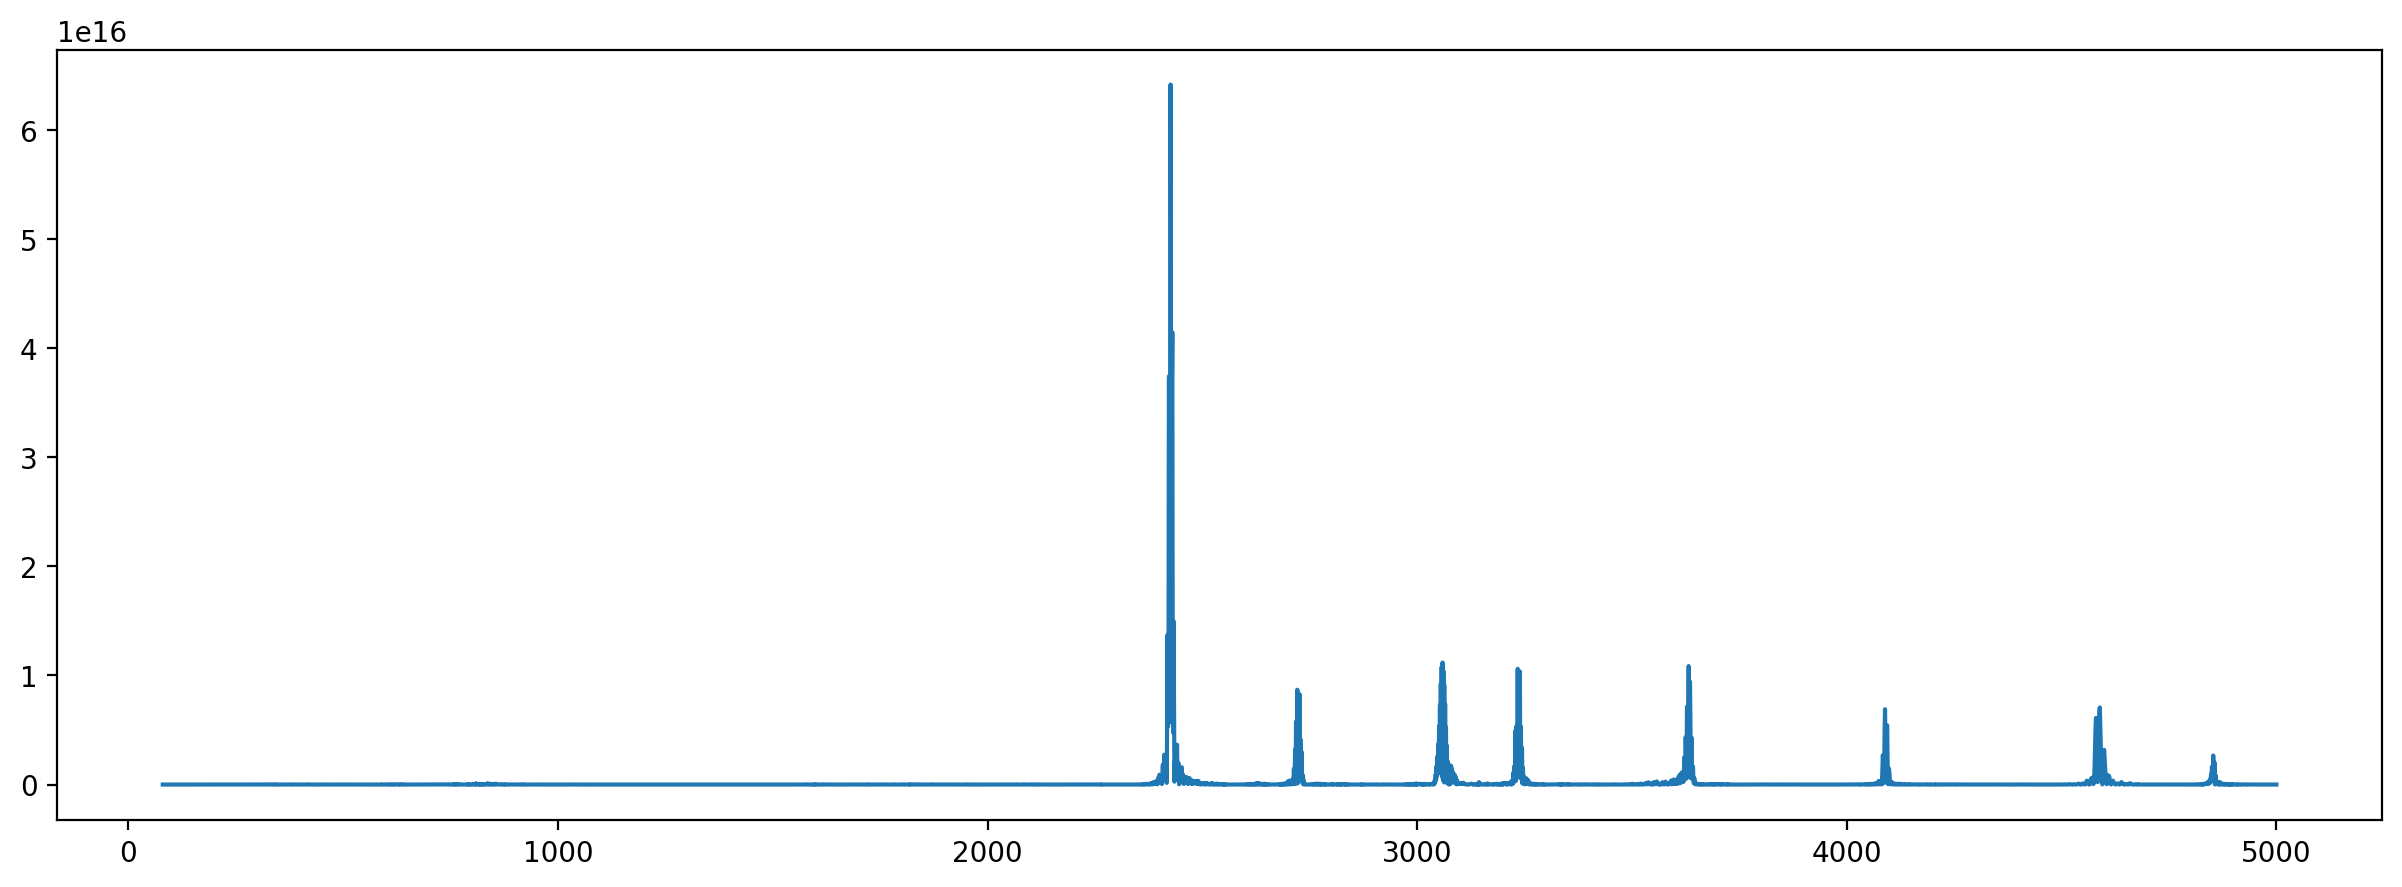

In [2]:
def fourier(x,k):
    n = len(x)
    j = np.arange(0,n)

    f_sin = np.sum(x * np.sin(2 * np.pi * j * k/n))
    f_cos = np.sum(x * np.cos(2 * np.pi * j * k/n))

    return f_sin**2 + f_cos**2

k1 = 80
k2 = 5000
frequency_indices = np.arange(80,5001)
frequency_indices_results = np.array([fourier(data,k) for k in frequency_indices])
plt.plot(frequency_indices,frequency_indices_results)

(4) Convert the frequencies indices 'k' for regular frequencies in units of Hertz (oscillations per second). Repeat the plot with frequency as the X axis.

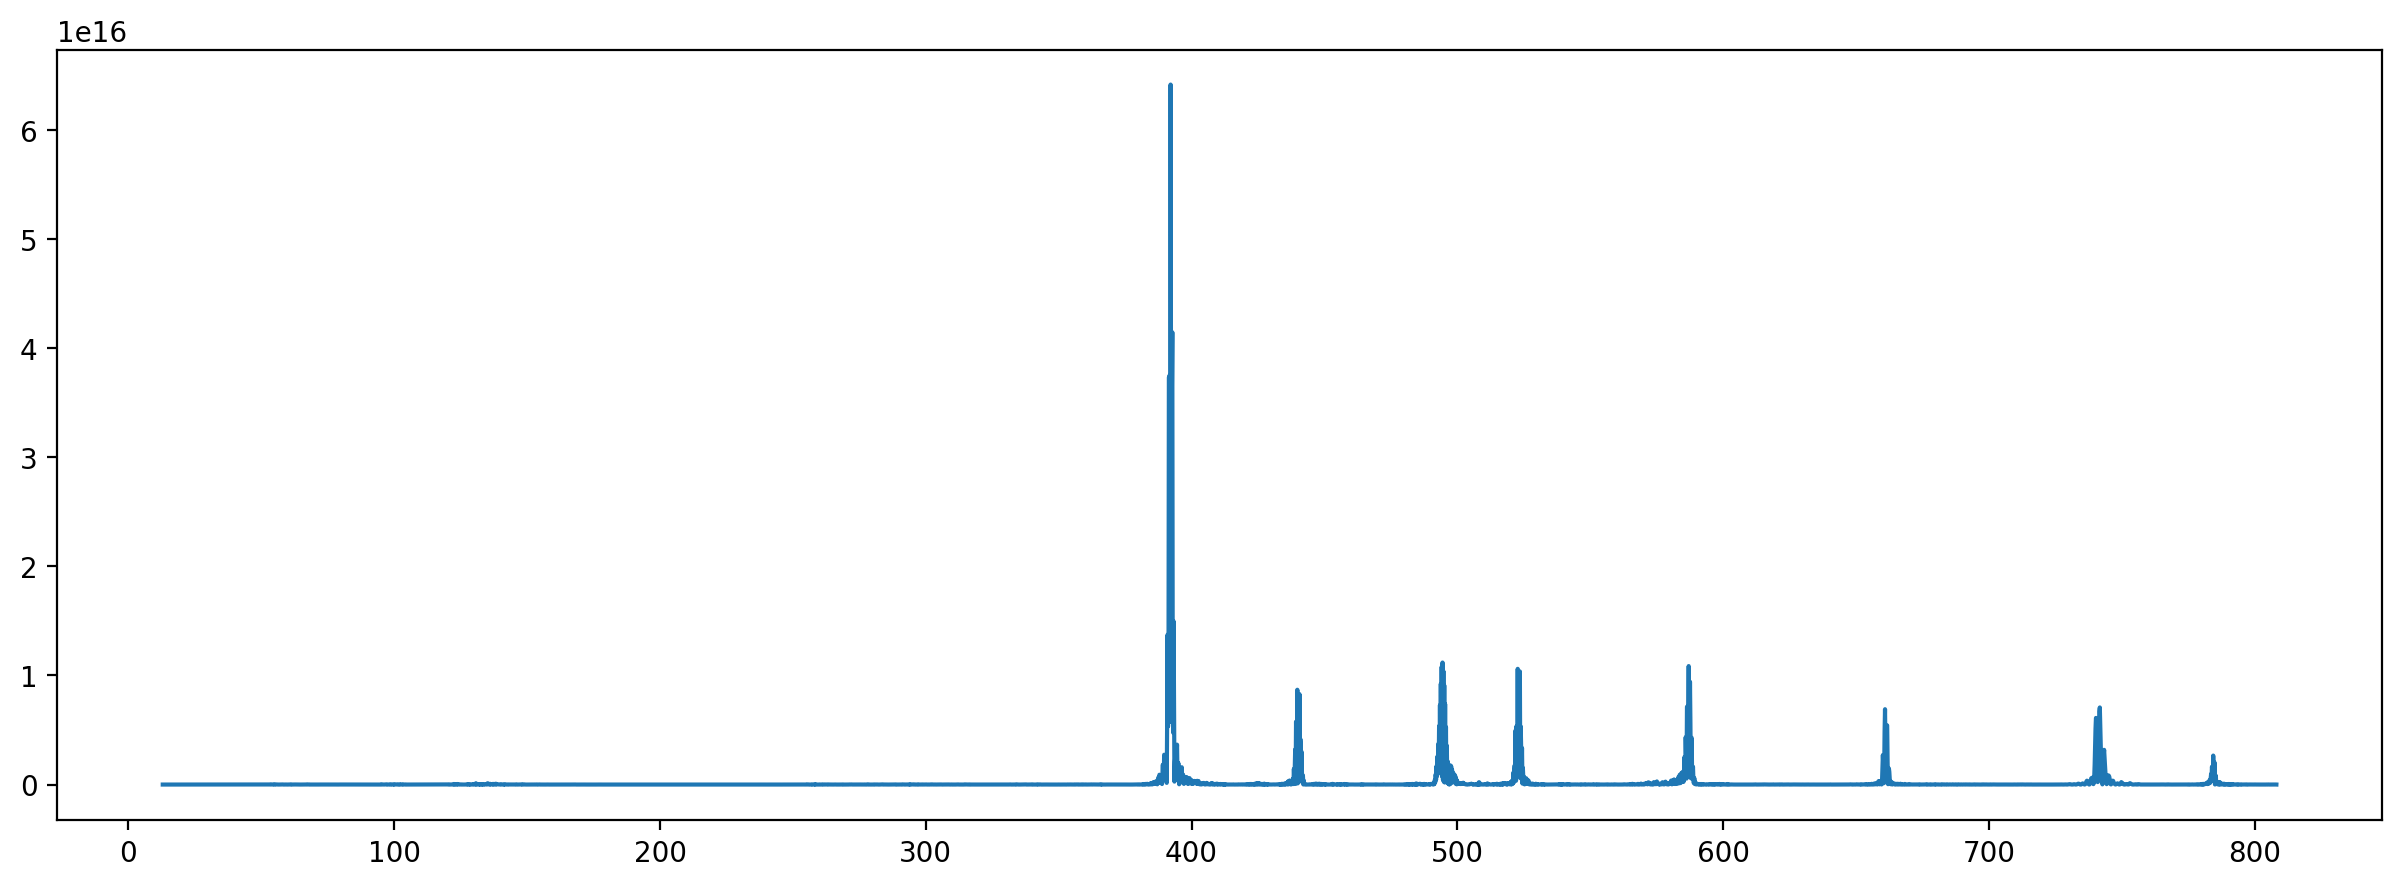

In [3]:
k1 = 80
k2 = 5000
frequency_indices = np.arange(80,5001)
frequency_hz = frequency_indices*(rate/len(data))
frequency_indices_results_hz = np.array([fourier(data,k) for k in frequency_indices])
plt.plot(frequency_hz,frequency_indices_results_hz)

(5) You should see a wide range of frequencies. Let's say the wave with the highest amplitude has a frequency f_max and an amplitude A_max. List the f_max in Hertz: 

In [4]:
peak_indices = np.argmax(frequency_indices_results_hz)
peak_frequency = frequency_hz[peak_indices]
print(peak_frequency)

392.1336206896552


In [ ]:
# f_max = 392.13 Hertz

(6) You should see a wide range of frequencies. Let's say the wave with the highest amplitude has a frequency f_max and an amplitude A_max. Print f_max in Hertz:

In [5]:
peak_indices = np.argmax(frequency_indices_results_hz)
peak_frequency = frequency_hz[peak_indices]
print(peak_frequency)

392.1336206896552


In [6]:
# f_max = 392.13 Hertz
#I think this is a repeat question

(7) To characterize the range of the present frequencies, print the lowest frequencies of all waves that have an amplidude of at least A_max/4.

In [7]:
threshold = np.max(frequency_indices_results_hz)/16
above_threshold_mask = frequency_indices_results_hz >= threshold
frequencies_above_threshold = frequency_hz[above_threshold_mask]
bin_width = frequency_hz[0]-frequency_hz[1]
frequency_jumps = np.diff(frequencies_above_threshold)>(1.5*bin_width) #here I am finding where the waves are
start_indices = np.where(frequency_jumps)[0]+1
start_indices = np.insert(start_indices,0,0)
for i in range(len(start_indices)):
    if i == len(start_indices) - 1:
        group_frequencies = frequencies_above_threshold[start_indices[i]:]
    else:
        group_frequencies = frequencies_above_threshold[start_indices[i]:start_indices[i+1]]
    if len(group_frequencies) > 0:
        min_frequency = group_frequencies[0]
        print(f"wave {i+1}: {min_frequency:.3f} Hz")

wave 1: 390.841 Hz
wave 2: 391.002 Hz
wave 3: 391.164 Hz
wave 4: 391.325 Hz
wave 5: 391.487 Hz
wave 6: 391.649 Hz
wave 7: 391.810 Hz
wave 8: 391.972 Hz
wave 9: 392.134 Hz
wave 10: 392.295 Hz
wave 11: 392.457 Hz
wave 12: 392.619 Hz
wave 13: 392.780 Hz
wave 14: 392.942 Hz
wave 15: 393.103 Hz
wave 16: 393.265 Hz
wave 17: 393.427 Hz
wave 18: 439.332 Hz
wave 19: 439.817 Hz
wave 20: 440.140 Hz
wave 21: 440.302 Hz
wave 22: 440.625 Hz
wave 23: 440.948 Hz
wave 24: 493.157 Hz
wave 25: 493.481 Hz
wave 26: 493.804 Hz
wave 27: 494.127 Hz
wave 28: 494.450 Hz
wave 29: 494.774 Hz
wave 30: 495.097 Hz
wave 31: 495.420 Hz
wave 32: 495.744 Hz
wave 33: 521.929 Hz
wave 34: 522.252 Hz
wave 35: 522.414 Hz
wave 36: 522.737 Hz
wave 37: 523.060 Hz
wave 38: 523.222 Hz
wave 39: 523.545 Hz
wave 40: 523.869 Hz
wave 41: 585.938 Hz
wave 42: 586.422 Hz
wave 43: 586.584 Hz
wave 44: 586.907 Hz
wave 45: 587.069 Hz
wave 46: 587.554 Hz
wave 47: 587.716 Hz
wave 48: 588.039 Hz
wave 49: 588.200 Hz
wave 50: 660.776 Hz
wave 51: 

(8) Now also print the highest frequencies of all waves that have an amplidude of at least A_max/4.

In [8]:
for i in range(len(start_indices)):
    if i == len(start_indices) - 1:
        group_frequencies = frequencies_above_threshold[start_indices[i]:]
    else:
        group_frequencies = frequencies_above_threshold[start_indices[i]:start_indices[i+1]]
    if len(group_frequencies) > 0:
        min_frequency = group_frequencies[-1]
        print(f"wave {i+1}: {min_frequency:.3f} Hz")

wave 1: 390.841 Hz
wave 2: 391.002 Hz
wave 3: 391.164 Hz
wave 4: 391.325 Hz
wave 5: 391.487 Hz
wave 6: 391.649 Hz
wave 7: 391.810 Hz
wave 8: 391.972 Hz
wave 9: 392.134 Hz
wave 10: 392.295 Hz
wave 11: 392.457 Hz
wave 12: 392.619 Hz
wave 13: 392.780 Hz
wave 14: 392.942 Hz
wave 15: 393.103 Hz
wave 16: 393.265 Hz
wave 17: 393.427 Hz
wave 18: 439.332 Hz
wave 19: 439.817 Hz
wave 20: 440.140 Hz
wave 21: 440.302 Hz
wave 22: 440.625 Hz
wave 23: 440.948 Hz
wave 24: 493.157 Hz
wave 25: 493.481 Hz
wave 26: 493.804 Hz
wave 27: 494.127 Hz
wave 28: 494.450 Hz
wave 29: 494.774 Hz
wave 30: 495.097 Hz
wave 31: 495.420 Hz
wave 32: 495.744 Hz
wave 33: 521.929 Hz
wave 34: 522.252 Hz
wave 35: 522.414 Hz
wave 36: 522.737 Hz
wave 37: 523.060 Hz
wave 38: 523.222 Hz
wave 39: 523.545 Hz
wave 40: 523.869 Hz
wave 41: 585.938 Hz
wave 42: 586.422 Hz
wave 43: 586.584 Hz
wave 44: 586.907 Hz
wave 45: 587.069 Hz
wave 46: 587.554 Hz
wave 47: 587.716 Hz
wave 48: 588.039 Hz
wave 49: 588.200 Hz
wave 50: 660.776 Hz
wave 51: 

Please upload your notebook and your recording in .wav format. Thank you!